In [64]:
import numpy as np
import statistics
import seaborn as sns
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits

In [65]:
df=pd.read_csv('Listings.csv',encoding="latin1")
features = [
    "price",
    "accommodates",
    "bedrooms",
    "minimum_nights",
    "maximum_nights",
    "host_total_listings_count",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "latitude",
    "longitude"
]


print(df[features].describe())

/tmp/ipykernel_18481/3069369883.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Listings.csv',encoding="latin1")


               price   accommodates       bedrooms  minimum_nights  \
count  279712.000000  279712.000000  250277.000000   279712.000000   
mean      608.792737       3.288736       1.515509        8.050967   
std      3441.826611       2.133379       1.153080       31.518946   
min         0.000000       0.000000       1.000000        1.000000   
25%        75.000000       2.000000       1.000000        1.000000   
50%       150.000000       2.000000       1.000000        2.000000   
75%       474.000000       4.000000       2.000000        5.000000   
max    625216.000000      16.000000      50.000000     9999.000000   

       maximum_nights  host_total_listings_count  review_scores_rating  \
count    2.797120e+05              279547.000000         188307.000000   
mean     2.755860e+04                  24.581612             93.405195   
std      7.282875e+06                 284.041143             10.070437   
min      1.000000e+00                   0.000000             20.000000   

In [21]:

X=df[features].dropna()
X=X[X['price']> 1000]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [22]:
def plot_correlation_circle(initial_variables, new_variables, feature_names,c1=0,c2=1, pc_labels=['PC1', 'PC2']):
    plt.figure(figsize=(8, 8))
    
    # Tracer un cercle unité
    circle = plt.Circle((0, 0), 1, color='gray', fill=False)
    plt.gca().add_artist(circle)
    
    # Tracer les flèches (correlations des variables)
    for i in range(len(feature_names)):
        x=np.corrcoef(new_variables[:,c1],initial_variables[:,i])[0,1]
        y=np.corrcoef(new_variables[:,c2],initial_variables[:,i])[0,1]
        plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.001, fc='red', ec='red')
        plt.text(x * 1.1, y * 1.1, feature_names[i], color='black', ha='center', va='center')
    
    # Ajustements esthétiques
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel(pc_labels[0])
    plt.ylabel(pc_labels[1])
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.title('Cercle de corrélation')
    plt.show()

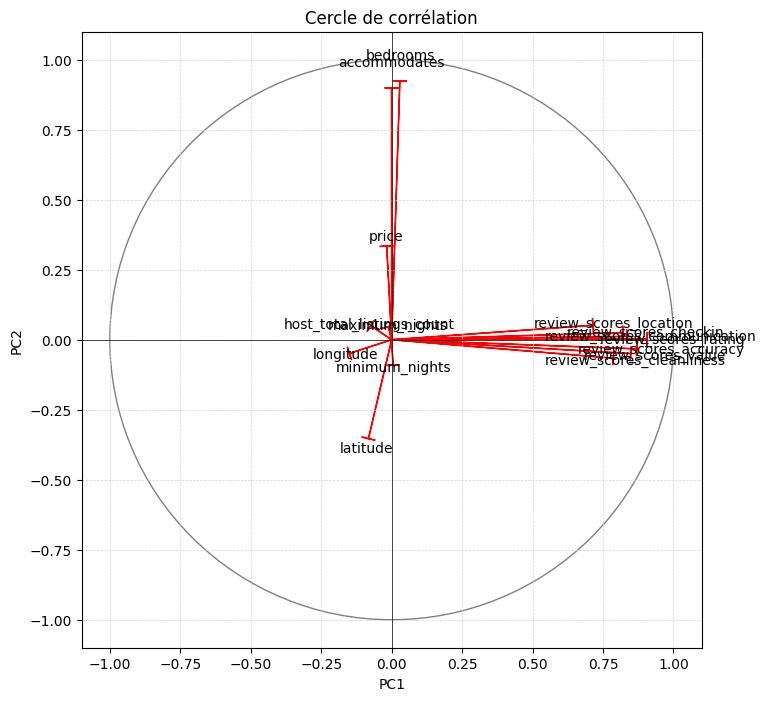

In [23]:
pca=PCA() #n_components=2)
X_pca=pca.fit_transform(X_scaled)

plot_correlation_circle(X_scaled,X_pca,features)


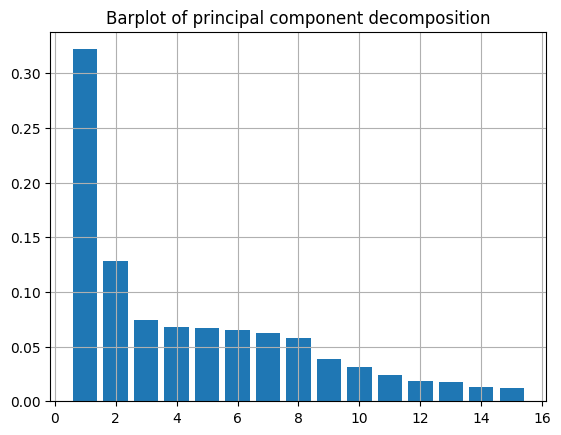

In [24]:

i=np.arange(1,pca.n_components_+1)
plt.bar(i,pca.explained_variance_ratio_)
plt.title('Barplot of principal component decomposition')
plt.grid()
plt.show()


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

price = X['prices']
sims = []
for comp in pca.components_:
    sims.append(cosine_similarity(price, comp))

print()

KeyError: 'prices'

In [ ]:
feature_names = features
price_idx = feature_names.index("price")

# -------------------------
# 5. Extract loadings
# -------------------------
loadings = []

for i, comp in enumerate(pca.components_):
    loading = comp[price_idx]
    loadings.append((i, loading))

# -------------------------
# 6. Sort by importance
# -------------------------
sorted_loadings = sorted(loadings, key=lambda x: abs(x[1]), reverse=True)

# -------------------------
# 7. Print results
# -------------------------
print("Components most related to PRICE:\n")

for i, val in sorted_loadings:
    print(f"Component {i+1}: loading = {val:.4f}")

Components most related to PRICE:

Component 7: loading = 0.8407
Component 8: loading = 0.3431
Component 2: loading = 0.2409
Component 3: loading = 0.1934
Component 6: loading = 0.1762
Component 4: loading = 0.1708
Component 5: loading = -0.1386
Component 11: loading = -0.0175
Component 14: loading = -0.0121
Component 15: loading = -0.0086
Component 1: loading = 0.0080
Component 10: loading = 0.0040
Component 9: loading = 0.0029
Component 12: loading = -0.0026
Component 13: loading = -0.0002


## **Unsupervised part of project**

In [ ]:
features = [
    "price",
    "accommodates",
    "bedrooms",
    "minimum_nights",
    "maximum_nights",
    "host_total_listings_count",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "latitude",
    "longitude"
]

# Ensure we only use paris listings
df_paris = df[df['city'] == 'Paris'].copy()

df_cleaned = df_paris[features].dropna(subset=['review_scores_rating'])

# Impute 'bedrooms' and 'host_count' with the median
df_cleaned['bedrooms'] = df_cleaned['bedrooms'].fillna(df_cleaned['bedrooms'].median())
df_cleaned['host_total_listings_count'] = df_cleaned['host_total_listings_count'].fillna(df_cleaned['host_total_listings_count'].median())
#df_cleaned = df_cleaned[df_cleaned['price']> 1000]

print(df_cleaned[features].isnull().sum())
df_cleaned = df_cleaned.dropna()
print(len(df_cleaned))

price                           0
accommodates                    0
bedrooms                        0
minimum_nights                  0
maximum_nights                  0
host_total_listings_count       0
review_scores_rating            0
review_scores_accuracy         54
review_scores_cleanliness      45
review_scores_checkin          71
review_scores_communication    52
review_scores_location         72
review_scores_value            71
latitude                        0
longitude                       0
dtype: int64
47941


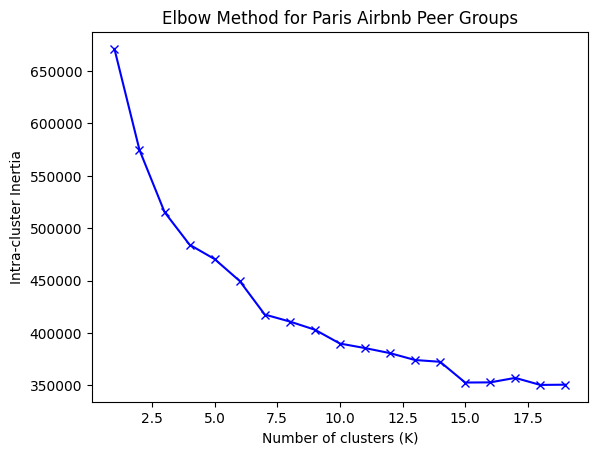

In [ ]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

# Features for clustering (excluding price)
cluster_features = [f for f in features if f != "price"]
X = df_cleaned[cluster_features]
scaler=StandardScaler()
X=scaler.fit_transform(X)

inertia = []
K_range = range(1, 20)

for k in K_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Intra-cluster Inertia')
plt.title('Elbow Method for Paris Airbnb Peer Groups')
plt.show()

We can see in the elbow plot ....

We chose K=10 for good granularity

In [106]:
from sklearn.cluster import MiniBatchKMeans

# Fit the final model
kmeans_final = MiniBatchKMeans(n_clusters=7, random_state=42, batch_size=1024)
df_cleaned['cluster_id'] = kmeans_final.fit_predict(X) # X is your normalized data

In [107]:
# Calculate mean and std price for each peer group
cluster_stats = df_cleaned.groupby('cluster_id')['price'].agg(['mean', 'std']).reset_index()
cluster_stats.columns = ['cluster_id', 'avg_price', 'std_price']

# Merge these stats back to the main dataframe
df_cleaned = df_cleaned.merge(cluster_stats, on='cluster_id')

In [108]:
# Sensitivity parameter
sensitivity = 0.3

# Calculate Robust Statistics for each cluster (as before)
cluster_robust_stats = df_cleaned.groupby('cluster_id')['price'].quantile([0.25, 0.75]).unstack()
cluster_robust_stats.columns = ['q1_price', 'q3_price']
cluster_robust_stats['iqr_price'] = cluster_robust_stats['q3_price'] - cluster_robust_stats['q1_price']
cluster_robust_stats['gem_threshold'] = cluster_robust_stats['q1_price'] - (sensitivity * cluster_robust_stats['iqr_price'])

# Remove any old threshold or is_gem columns if they exist
cols_to_remove = [c for c in df_cleaned.columns if 'gem_threshold' in c or 'is_gem' in c]
df_cleaned = df_cleaned.drop(columns=cols_to_remove)

# Merge back to the main dataframe safely
# We reset_index on cluster_robust_stats because 'cluster_id' is currently its index
df_cleaned = df_cleaned.merge(cluster_robust_stats[['gem_threshold']], on='cluster_id')

# Apply the final Label
df_cleaned['is_gem'] = (df_cleaned['price'] < df_cleaned['gem_threshold']).astype(int)

# Check the distribution
print(df_cleaned['is_gem'].value_counts(normalize=True))

is_gem
0    0.901629
1    0.098371
Name: proportion, dtype: float64


Missing Latitude: 0
Missing Longitude: 0
Plotting 47941 points...


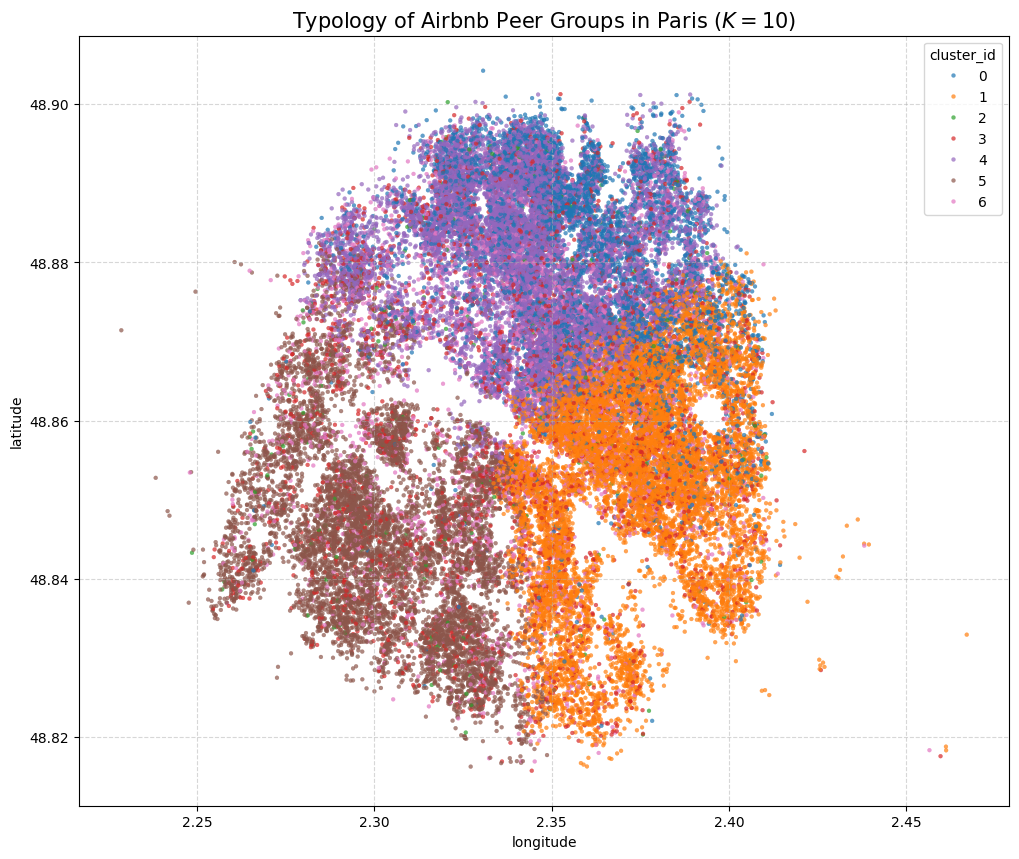

In [109]:
# Check if there are NaNs in the coordinates first
print("Missing Latitude:", df_cleaned['latitude'].isnull().sum())
print("Missing Longitude:", df_cleaned['longitude'].isnull().sum())

print(f"Plotting {len(df_cleaned)} points...")

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_cleaned, 
    x='longitude',    
    y='latitude',      
    hue='cluster_id', 
    palette='tab10',
    s=8,              
    alpha=0.7, 
    edgecolor=None
)

plt.title("Typology of Airbnb Peer Groups in Paris ($K=10$)", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [110]:
# Create a typology table using Medians (Robust to outliers)
typology = df_cleaned.groupby('cluster_id')[features].median()

# Add a count to see how big each group is
typology['count'] = df_cleaned.groupby('cluster_id').size()

# Sort by rating to find the "Bad" cluster immediately
print(typology[['price', 'review_scores_rating', 'review_scores_location', 'count']].sort_values(by='review_scores_rating'))

            price  review_scores_rating  review_scores_location  count
cluster_id                                                            
2            80.0                  40.0                     7.0    394
3            76.0                  80.0                    10.0   4715
0            65.0                  91.0                     9.0   6985
5            80.0                  96.0                    10.0   7830
6           185.0                  96.0                    10.0   4682
1            75.0                  97.0                    10.0  11943
4            79.0                  98.0                    10.0  11392


In [111]:
# Calculate the percentage of gems in each cluster
gem_stats = df_cleaned.groupby('cluster_id')['is_gem'].mean() * 100
gem_stats = gem_stats.reset_index()
gem_stats.columns = ['cluster_id', 'gem_percentage']

# Sort by percentage to see where the "Value" is concentrated
print(gem_stats.sort_values(by='gem_percentage', ascending=False))

   cluster_id  gem_percentage
4           4       12.306882
0           0       10.307802
1           1        9.804907
5           5        9.003831
3           3        8.695652
6           6        6.108501
2           2        5.583756


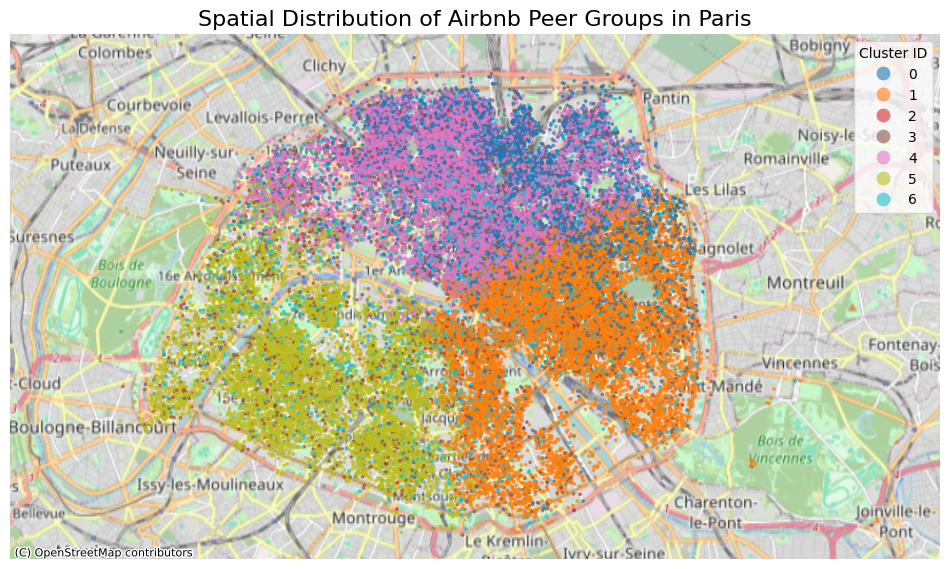

In [112]:
import geopandas as gpd
import contextily as ctx

# Convert df_paris to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_cleaned, 
    geometry=gpd.points_from_xy(df_cleaned.longitude, df_cleaned.latitude),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 12))

gdf.plot(
    ax=ax,
    column='cluster_id', 
    categorical=True, 
    legend=True, 
    markersize=3,       # Keep points small so the map is visible
    alpha=0.6, 
    cmap='tab10',
    legend_kwds={'title': "Cluster ID", 'bbox_to_anchor': (1, 1)}
)

# Add the Paris background map
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off() 
plt.title("Spatial Distribution of Airbnb Peer Groups in Paris", fontsize=16)
plt.show()

## **Supervised part of project**